# TP1 · Notebook 04 — Modelo VAR, causalidad de Granger e impulso-respuesta
Puntos 10 y 11 de la consigna. A diferencia del Notebook 03 (donde `SARIMAX` diferenciaba internamente), el VAR
exige las tres series **ya estacionarias** antes de entrar al modelo: se usan las columnas `_estacionaria` que
exportó el Notebook 02, cada una con su transformación y sus $(d, D)$.

## 1. Entorno y carga de los insumos del Notebook 02

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings, os, glob
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (13, 4.5), 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 10})

# ---------------- configuración ----------------
NOMBRE_CARPETA = 'DATASETS'
RUTA_DIRECTA   = '/content/drive/MyDrive/TP Analisis de Series Temporales/DATASETS'
S = 12
COLORES = {'nieve': 'steelblue', 'savi': 'seagreen', 'agua': 'indianred'}
# -----------------------------------------------

try:
    from google.colab import drive; drive.mount('/content/drive', force_remount=False)
except ImportError:
    pass

CARPETA_DATOS = RUTA_DIRECTA if os.path.isdir(RUTA_DIRECTA) else next(
    (h for raiz in ['/content/drive/MyDrive', '/content', '.'] for n in range(4)
     for h in glob.glob(os.path.join(raiz, *(['*'] * n), NOMBRE_CARPETA)) if os.path.isdir(h)), None)
assert CARPETA_DATOS, f'No se encontró la carpeta {NOMBRE_CARPETA}. Ajustar RUTA_DIRECTA.'
CARPETA_SALIDA = os.path.join(CARPETA_DATOS.rsplit('/', 1)[0], 'OUTPUTS')
os.makedirs(CARPETA_SALIDA, exist_ok=True)

localizar = lambda p: next(iter(sorted(glob.glob(os.path.join(CARPETA_SALIDA, '**', p), recursive=True))), None)
p_series, p_decision = localizar('02_series_estacionarizadas.csv'), localizar('02_decision_ordenes.csv')
assert p_series and p_decision, 'Faltan los CSV del Notebook 02: ejecutarlo antes que este notebook.'

df_series   = pd.read_csv(p_series, index_col=0, parse_dates=True).asfreq('MS')
df_decision = pd.read_csv(p_decision, index_col=0)
VARIABLES   = ['nieve', 'savi', 'agua']

ORDENES        = {k: {'d': int(df_decision.loc[k, 'd']), 'D': int(df_decision.loc[k, 'D'])} for k in VARIABLES}
TRANSFORMACION = {k: df_decision.loc[k, 'transformación'] for k in VARIABLES}
TRANSFORMADAS  = {k: df_series[f'{k}_transformada'].dropna() for k in VARIABLES}   # para reintegrar
ESTACIONARIAS  = {k: df_series[f'{k}_estacionaria'].dropna() for k in VARIABLES}   # entrada del VAR

# Opcional: resumen del NB03, sólo para comparar pronósticos en la sección 8
p_res = localizar('03_resumen_modelos_sarima.csv')
resumen_sarima = pd.read_csv(p_res, index_col=0) if p_res else None
print('resumen_modelos_sarima.csv:', 'encontrado' if p_res else 'no encontrado (se omite la comparación)')

for k in VARIABLES:
    print(f'{k:6s} transf.: {TRANSFORMACION[k]:8s} d={ORDENES[k]["d"]} D={ORDENES[k]["D"]}  '
          f'n estacionaria={len(ESTACIONARIAS[k])} ({ESTACIONARIAS[k].index.min():%Y-%m} a '
          f'{ESTACIONARIAS[k].index.max():%Y-%m})')

Mounted at /content/drive
resumen_modelos_sarima.csv: encontrado
nieve  transf.: log      d=0 D=0  n estacionaria=471 (1986-01 a 2025-03)
savi   transf.: ninguna  d=1 D=1  n estacionaria=92 (2017-08 a 2025-03)
agua   transf.: ninguna  d=1 D=0  n estacionaria=104 (2016-08 a 2025-03)


## 2. Ventana común estacionaria

El VAR necesita las tres series simultáneamente, así que la ventana de trabajo es la **intersección** de las tres
`_estacionaria`: más corta que los 105 meses del NB01, acotada por `savi`, que pierde 13 observaciones por su
doble diferenciación ($d=1$, $D=1$).

Ventana común post-diferenciación: 2017-08 a 2025-03 (n = 92)


,nieve,savi,agua
count,92.0000,92.0000,92.0000
mean,7.0847,-0.0006,-2.9812
std,1.6719,0.0254,39.8267
min,4.3663,-0.0885,-138.7557
25%,5.6180,-0.0122,-23.0418
50%,6.9245,0.0016,-2.4877
75%,8.1366,0.0103,12.1358
max,10.9422,0.0735,165.5961


ADF dentro de la ventana común:
  nieve  ADF= -4.719  p=0.0001  (estacionaria)
  savi   ADF=-11.938  p=0.0000  (estacionaria)
  agua   ADF= -5.596  p=0.0000  (estacionaria)


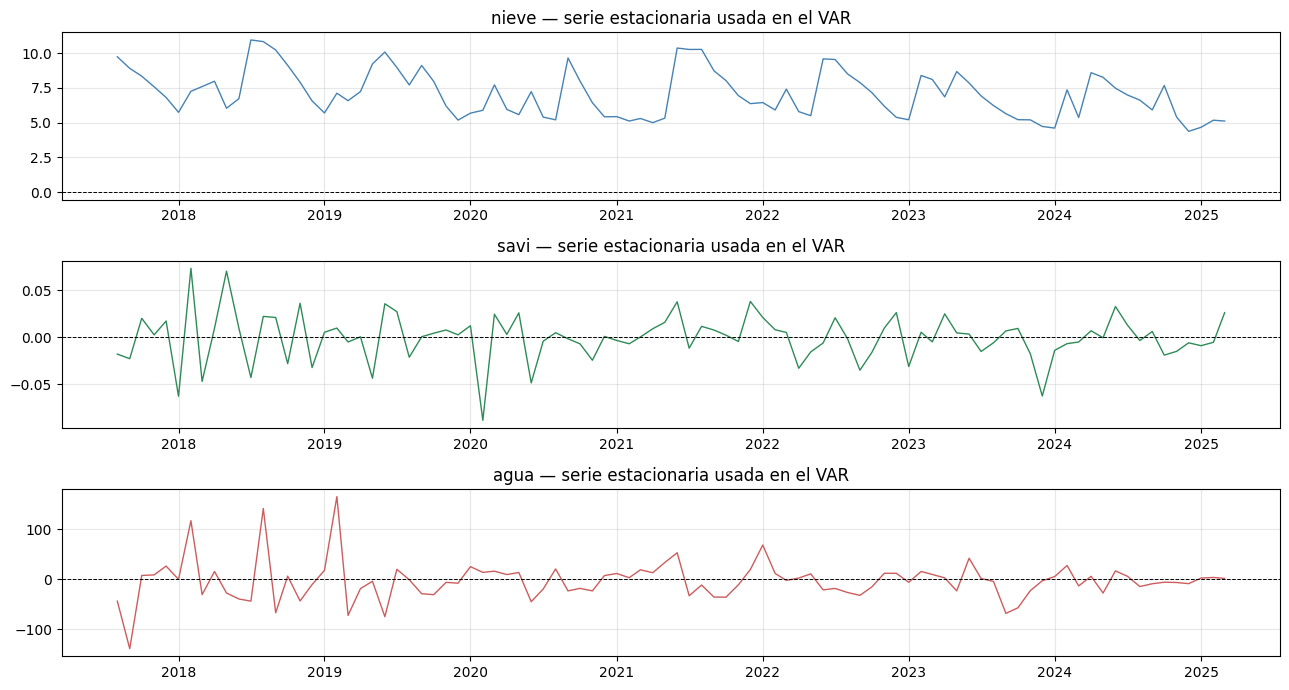

In [2]:
common = pd.concat(ESTACIONARIAS, axis=1).dropna()
common.columns = VARIABLES

print(f'Ventana común post-diferenciación: {common.index.min():%Y-%m} a {common.index.max():%Y-%m} '
      f'(n = {len(common)})')
display(common.describe().round(4))

# Verificación (no repite la batería completa del NB02): ¿siguen estacionarias en esta ventana más corta?
print('ADF dentro de la ventana común:')
for c in common.columns:
    est, p, *_ = adfuller(common[c], autolag='AIC')
    print(f'  {c:6s} ADF={est:7.3f}  p={p:.4f}  {"(estacionaria)" if p < 0.05 else "(revisar)"}')

fig, axes = plt.subplots(3, 1, figsize=(13, 7))
for ax, c in zip(axes, common.columns):
    ax.plot(common.index, common[c], color=COLORES[c], lw=1)
    ax.axhline(0, color='black', lw=0.7, ls='--')
    ax.set_title(f'{c} — serie estacionaria usada en el VAR')
plt.tight_layout(); plt.show()

## 3. Selección del orden y estimación del VAR *(punto 10)*

Se prueba hasta 12 rezagos (`nieve` y `agua` conservan su ciclo estacional, $D=0$ en ambas) y se comparan los
cuatro criterios. Luego se verifica **estabilidad** (raíces con módulo > 1) y los supuestos sobre los residuos.

In [3]:
modelo_var = VAR(common)
seleccion = modelo_var.select_order(maxlags=12)
print(seleccion.summary())
print('\nÓrdenes que minimizan cada criterio:', seleccion.selected_orders)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.5498      0.6391       1.733      0.5856
1       0.1518     0.5091*      1.164*     0.2950*
2       0.2809      0.9062       1.326      0.5316
3       0.3335       1.227       1.401      0.6916
4       0.3390       1.500       1.416      0.8046
5       0.4310       1.860       1.564       1.004
6       0.4343       2.131       1.587       1.115
7       0.4263       2.392       1.600       1.214
8       0.1722       2.405       1.268       1.068
9       0.1614       2.663       1.289       1.164
10      0.2220       2.991       1.419       1.332
11      0.1637       3.201       1.400       1.381
12     0.1466*       3.452       1.454       1.472
--------------------------------------------------

Órdenes que minimizan cada criterio: {'aic': np.int64(12), 'bic': np.int64(1), 'hqic': np.int64(1), 'fpe': np.int64(1)}


In [4]:
# ---- Decisión tomada según la tabla anterior ----
# BIC, HQIC y FPE coinciden en 1; el AIC prefiere un orden alto por sobreajuste con sólo ~92 obs.
P_VAR = 1

resultado_var = modelo_var.fit(P_VAR)
print(resultado_var.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 23, Aug, 2026
Time:                     00:25:54
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   0.904832
Nobs:                     91.0000    HQIC:                  0.707309
Log likelihood:          -401.475    FPE:                    1.77518
AIC:                     0.573730    Det(Omega_mle):         1.56025
--------------------------------------------------------------------
Results for equation nieve
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            2.735412         0.629149            4.348           0.000
L1.nieve         0.608423         0.086418            7.041           0.000
L1.savi         -1.836926         5.846109           -0.314           0.753
L1.a

In [5]:
print('Raíces del polinomio característico (módulo > 1 = estable):')
print(np.round(resultado_var.roots, 3), '| ¿estable?', resultado_var.is_stable())

print('\nCorrelación de los residuos:')
display(pd.DataFrame(resultado_var.resid_corr, index=common.columns, columns=common.columns).round(3))

print('\nBlancura de los residuos (H0: sin autocorrelación hasta el rezago 12):')
print(resultado_var.test_whiteness(nlags=12))
print('\nNormalidad multivariada (H0: residuos normales):')
print(resultado_var.test_normality())

Raíces del polinomio característico (módulo > 1 = estable):
[-13.338  -4.383   1.697] | ¿estable? True

Correlación de los residuos:


,nieve,savi,agua
nieve,1.000,0.052,0.044
savi,0.052,1.000,0.272
agua,0.044,0.272,1.000



Blancura de los residuos (H0: sin autocorrelación hasta el rezago 12):
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: reject at 5% significance level. Test statistic: 133.261, critical value: 123.225>, p-value: 0.012>

Normalidad multivariada (H0: residuos normales):
<statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data generated by normally-distributed process: reject at 5% significance level. Test statistic: 202.559, critical value: 12.592>, p-value: 0.000>


## 4. Causalidad de Granger *(punto 11)*

Las seis direcciones rezagadas (test $F$) más la **causalidad instantánea** de cada variable contra el resto del
sistema, que es la que capta relaciones contemporáneas como la de `agua`–`savi`.

In [6]:
tabla_granger = pd.DataFrame(
    [{'causante': a, 'causada': b,
      'F': (t := resultado_var.test_causality(b, [a], kind='f')).test_statistic,
      'p-valor': t.pvalue, '¿causa? (5%)': 'Sí' if t.pvalue < 0.05 else 'No'}
     for a in common.columns for b in common.columns if a != b])
print('=== Causalidad de Granger (rezagada), las seis direcciones ===')
display(tabla_granger.set_index(['causante', 'causada']).round(4))

print('\n=== Causalidad instantánea (cada variable vs. el resto del sistema) ===')
display(pd.DataFrame(
    [{'variable': v, 'estadístico': (t := resultado_var.test_inst_causality(v)).test_statistic,
      'p-valor': t.pvalue, '¿instantánea? (5%)': 'Sí' if t.pvalue < 0.05 else 'No'}
     for v in common.columns]).set_index('variable').round(4))

=== Causalidad de Granger (rezagada), las seis direcciones ===


F  p-valor ¿causa? (5%)
causante causada                              
nieve    savi     1.9607   0.1626           No
         agua     4.5117   0.0346           Sí
savi     nieve    0.0987   0.7536           No
         agua     1.3184   0.2519           No
agua     nieve    0.2049   0.6512           No
         savi     0.2277   0.6336           No


=== Causalidad instantánea (cada variable vs. el resto del sistema) ===


,estadístico,p-valor,¿instantánea? (5%)
variable,,,
nieve,0.3291,0.8483,No
savi,6.4070,0.0406,Sí
agua,6.3537,0.0417,Sí


## 5. Impulso-respuesta y descomposición de la varianza *(punto 11)*

Ortogonalización de Cholesky en el orden **nieve → agua → savi**, siguiendo la cadena hidrológica: `nieve` es la
más exógena (depende del clima, no de las otras dos) y `savi` la más aguas abajo. El orden afecta a la IRF —no a
la significatividad de Granger—, por eso se justifica con teoría. La FEVD complementa: qué porcentaje de la
varianza del error de pronóstico de cada variable aporta cada shock.

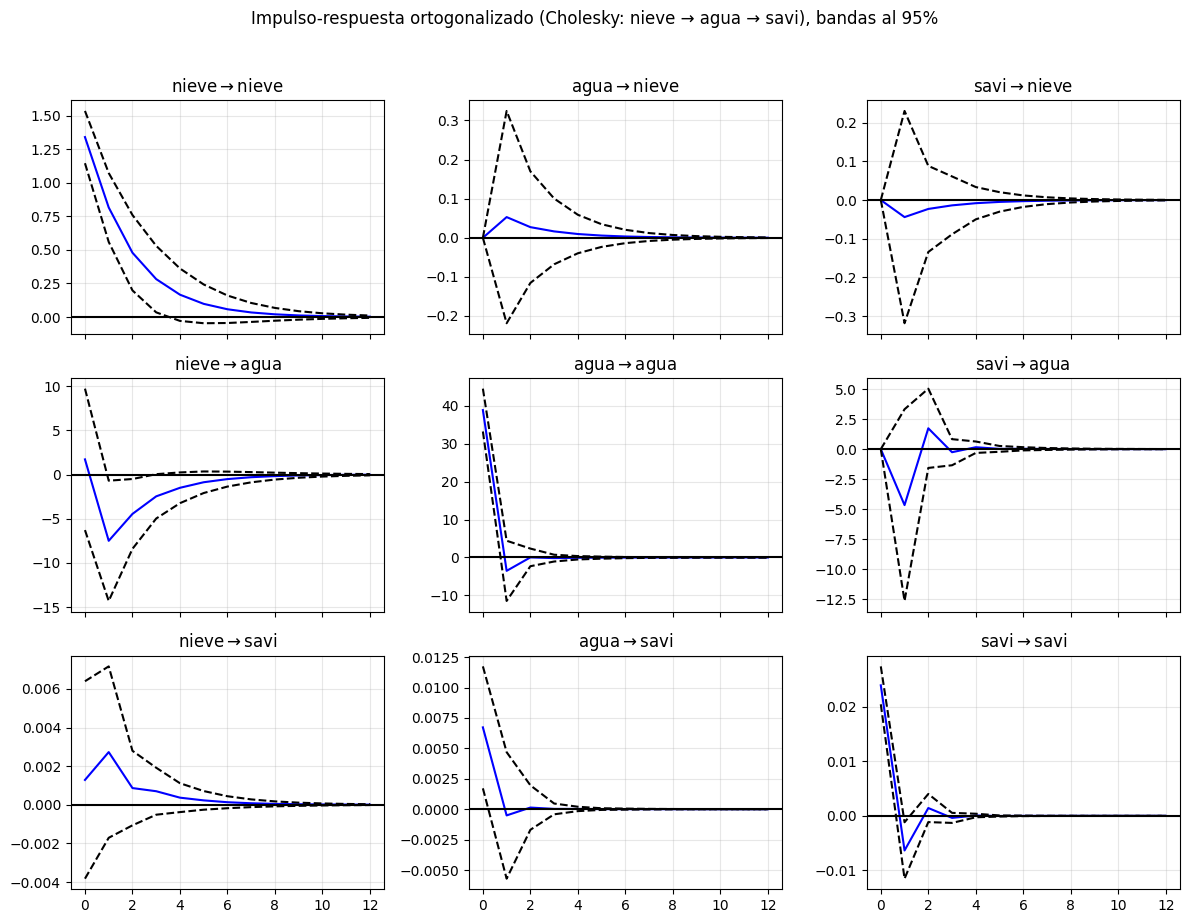

nieve  horizonte 12: {'nieve': np.float64(0.998), 'agua': np.float64(0.001), 'savi': np.float64(0.001)}
agua   horizonte 12: {'nieve': np.float64(0.054), 'agua': np.float64(0.931), 'savi': np.float64(0.015)}
savi   horizonte 12: {'nieve': np.float64(0.016), 'agua': np.float64(0.068), 'savi': np.float64(0.916)}


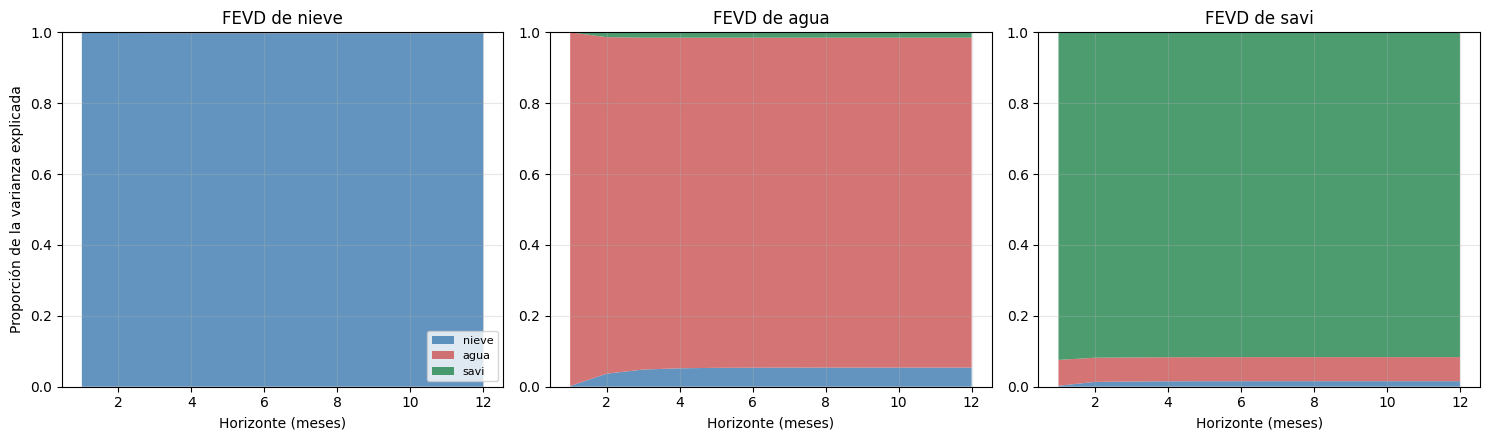

In [7]:
orden_causal = ['nieve', 'agua', 'savi']
modelo_irf = VAR(common[orden_causal]).fit(P_VAR)

fig = modelo_irf.irf(12).plot(orth=True, signif=0.05, figsize=(12, 9))
fig.suptitle('Impulso-respuesta ortogonalizado (Cholesky: nieve → agua → savi), bandas al 95%', y=1.02)
plt.tight_layout(); plt.show()

fevd = modelo_irf.fevd(12)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, var in zip(axes, orden_causal):
    tabla = pd.DataFrame(fevd.decomp[orden_causal.index(var)], columns=orden_causal)
    ax.stackplot(range(1, 13), [tabla[c] for c in orden_causal], labels=orden_causal,
                 colors=[COLORES[c] for c in orden_causal], alpha=0.85)
    ax.set(title=f'FEVD de {var}', xlabel='Horizonte (meses)', ylim=(0, 1))
    print(f'{var:6s} horizonte 12:', {c: round(tabla[c].iloc[-1], 3) for c in orden_causal})
axes[0].set_ylabel('Proporción de la varianza explicada')
axes[0].legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

## 6. Pronóstico del VAR: training vs. testing

Mismo horizonte de 12 meses que el Notebook 03, y —como la ventana común arranca en 2017-08— exactamente el mismo
tramo de testing que los SARIMA de `savi` y `agua`, así que la comparación es directa.

El VAR pronostica en la **escala diferenciada**: para volver a la original hay que reintegrar (deshacer $d$ y $D$
acumulando sobre el último valor observado) y luego deshacer la transformación de varianza.

In [8]:
def reintegrar(pron_diff, historia_transformada, d=0, D=0, s=S):
    '''Reconstruye el nivel transformado a partir de un pronóstico en escala diferenciada,
    usando la cola de la serie histórica transformada como ancla.'''
    idx = pron_diff.index

    if d > 0:                       # deshacer las d diferencias regulares -> W_t = (1-L^s)^D Y_t
        w_hist = historia_transformada.copy()
        for _ in range(D):
            w_hist = w_hist.diff(s)
        w, prev = pd.Series(index=idx, dtype=float), w_hist.dropna().iloc[-1]
        for t in idx:
            prev += pron_diff.loc[t]
            w.loc[t] = prev
    else:
        w = pron_diff.copy()

    if D > 0:                       # deshacer la diferencia estacional -> Y_t = Y_{t-s} + W_t
        combinado = pd.concat([historia_transformada.copy(), pd.Series(index=idx, dtype=float)])
        for t in idx:
            combinado.loc[t] = combinado.loc[t - pd.DateOffset(months=s)] + w.loc[t]
        return combinado.loc[idx]
    return w


invertir = lambda nombre, x: np.expm1(x) if TRANSFORMACION[nombre] == 'log' else x

def metricas(y_real, y_pred):
    e = np.asarray(y_real) - np.asarray(y_pred)
    return (np.mean(np.abs(e)), np.sqrt(np.mean(e**2)),
            100 * np.mean(2 * np.abs(e) / (np.abs(y_real) + np.abs(y_pred) + 1e-9)))

Training: 80 obs (2017-08 a 2024-03) | Testing: 12 obs (2024-04 a 2025-03)


,MAE,RMSE,sMAPE %
serie,,,
nieve,1363.780,1880.674,114.248
savi,0.038,0.043,22.194
agua,34.054,36.797,58.758


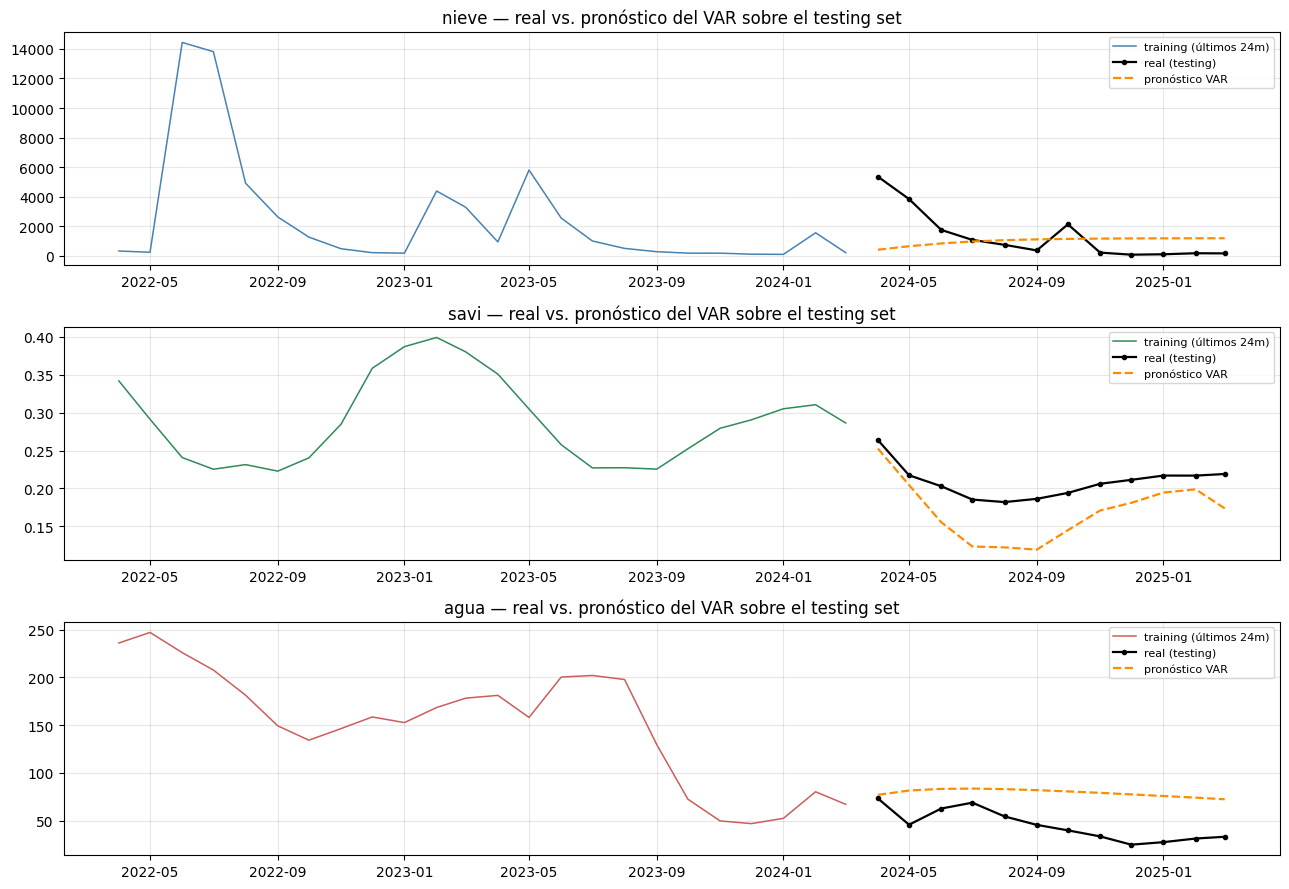

,SARIMA (NB03) — sMAPE %,VAR (NB04) — sMAPE %,Gana
serie,,,
nieve,119.46,114.25,VAR
savi,19.56,22.19,SARIMA
agua,84.87,58.76,VAR


`nieve` no es estrictamente comparable: el NB03 usó 24 meses de testing sobre los 471 de la serie.


In [9]:
N_TEST = 12
train, test = common.iloc[:-N_TEST], common.iloc[-N_TEST:]
print(f'Training: {len(train)} obs ({train.index[0]:%Y-%m} a {train.index[-1]:%Y-%m}) | '
      f'Testing: {len(test)} obs ({test.index[0]:%Y-%m} a {test.index[-1]:%Y-%m})')

# Se mantiene P_VAR: en el subconjunto de entrenamiento el AIC vuelve a preferir un orden alto
# por el mismo efecto de sobreajuste, mientras BIC, HQIC y FPE confirman el mismo orden.
resultado_train = VAR(train).fit(P_VAR)
pron_diff = pd.DataFrame(resultado_train.forecast(train.values[-P_VAR:], steps=N_TEST),
                         index=test.index, columns=common.columns)

filas, pron_orig = [], {}
for nombre in VARIABLES:
    pron_orig[nombre] = invertir(nombre, reintegrar(pron_diff[nombre],
                                                    TRANSFORMADAS[nombre].loc[:train.index[-1]],
                                                    **ORDENES[nombre]))
    y_real = invertir(nombre, TRANSFORMADAS[nombre].loc[test.index])
    filas.append({'serie': nombre, **dict(zip(['MAE', 'RMSE', 'sMAPE %'],
                                              metricas(y_real.values, pron_orig[nombre].values)))})
metricas_var = pd.DataFrame(filas).set_index('serie').round(3)
display(metricas_var)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
for ax, nombre in zip(axes, VARIABLES):
    ax.plot(invertir(nombre, TRANSFORMADAS[nombre].loc[train.index[-24:]]), color=COLORES[nombre],
            lw=1.1, label='training (últimos 24m)')
    ax.plot(invertir(nombre, TRANSFORMADAS[nombre].loc[test.index]), color='black', lw=1.6,
            marker='o', ms=3, label='real (testing)')
    ax.plot(pron_orig[nombre], color='darkorange', lw=1.6, ls='--', label='pronóstico VAR')
    ax.set_title(f'{nombre} — real vs. pronóstico del VAR sobre el testing set')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Comparación con los SARIMA univariados del NB03 (misma ventana de testing salvo en `nieve`)
if resumen_sarima is not None:
    comp = pd.DataFrame({'SARIMA (NB03) — sMAPE %': resumen_sarima['sMAPE test %'],
                         'VAR (NB04) — sMAPE %': metricas_var['sMAPE %']})
    comp['Gana'] = np.where(comp['VAR (NB04) — sMAPE %'] < comp['SARIMA (NB03) — sMAPE %'], 'VAR', 'SARIMA')
    display(comp.round(2))
    print('`nieve` no es estrictamente comparable: el NB03 usó 24 meses de testing sobre los 471 de la serie.')

## 7. Pronóstico final

Se reestima el VAR sobre las observaciones completas y se pronostican 12 meses, reintegrando cada serie a su
escala original. No se propaga la incertidumbre a través de la reintegración (requeriría simulación o bootstrap):
se reporta sólo el pronóstico puntual.

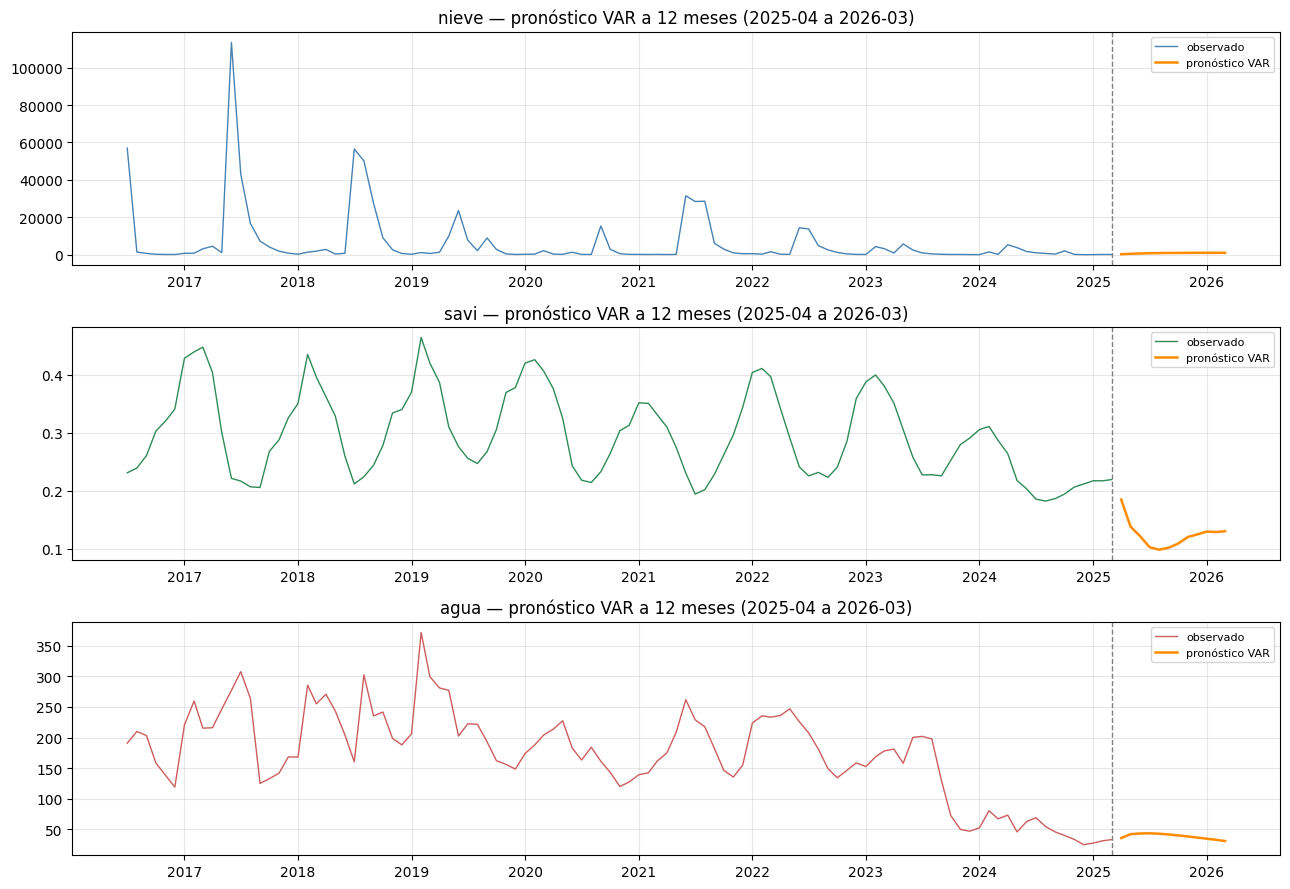

In [10]:
H = 12
idx_futuro = pd.date_range(common.index[-1] + pd.DateOffset(months=1), periods=H, freq='MS')
pron_full_diff = pd.DataFrame(resultado_var.forecast(common.values[-P_VAR:], steps=H),
                              index=idx_futuro, columns=common.columns)

fig, axes = plt.subplots(3, 1, figsize=(13, 9))
pronosticos_finales = {}
for ax, nombre in zip(axes, VARIABLES):
    historia = TRANSFORMADAS[nombre].dropna()
    y_pred = invertir(nombre, reintegrar(pron_full_diff[nombre], historia, **ORDENES[nombre]))
    pronosticos_finales[nombre] = y_pred
    ax.plot(invertir(nombre, historia.loc['2016-07':]), color=COLORES[nombre], lw=1, label='observado')
    ax.plot(y_pred, color='darkorange', lw=1.8, label='pronóstico VAR')
    ax.axvline(common.index[-1], color='grey', ls='--', lw=1)
    ax.set_title(f'{nombre} — pronóstico VAR a {H} meses '
                 f'({y_pred.index[0]:%Y-%m} a {y_pred.index[-1]:%Y-%m})')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Exportación

In [11]:
resumen_var = metricas_var.copy()
resumen_var['orden_VAR'] = P_VAR
resumen_var['n_estimacion'] = len(common)

for nombre, obj, kw in [('04_resumen_var.csv', resumen_var, {}),
                        ('04_granger_causalidad.csv', tabla_granger, {'index': False})]:
    ruta = os.path.join(CARPETA_SALIDA, nombre)
    obj.to_csv(ruta, **kw)
    print(f'{nombre}  ({os.path.getsize(ruta)/1024:.1f} KB)  ->  {os.path.abspath(ruta)}')

04_resumen_var.csv  (0.1 KB)  ->  /content/drive/MyDrive/TP Analisis de Series Temporales/OUTPUTS/04_resumen_var.csv
04_granger_causalidad.csv  (0.3 KB)  ->  /content/drive/MyDrive/TP Analisis de Series Temporales/OUTPUTS/04_granger_causalidad.csv
